In [1]:
import pandas as pd

data = pd.read_csv('../combined_dataset.csv')
data.fillna(0, inplace=True)

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

features = data.drop(['Algorithm', 'Socket', 'Start Time', 'End Time', 'Write Bytes', 'CPU Count', 'Num Files'], axis=1)
target = data['Algorithm']

X_train, X_test, y_train, y_test = train_test_split(features, target, test_size=0.33, random_state=0)

# Apply feature scaling
scaler = StandardScaler()
X_train_norm = scaler.fit_transform(X_train)
X_test_norm = scaler.transform(X_test)

In [3]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import seaborn as sns

K = range(2, 8)
fits = []
scores = []

for k in K:
    model = KMeans(n_clusters=k, random_state = 0, n_init='auto').fit(X_train_norm)
    fits.append(model)
    score = silhouette_score(X_train_norm, model.labels_, metric='euclidean')
    scores.append(score)
    print(f"For {k} clusters, the score is: {score}")

For 2 clusters, the score is: 0.42651067570308204
For 3 clusters, the score is: 0.2535086456892791
For 4 clusters, the score is: 0.3083023980154136
For 5 clusters, the score is: 0.31296217692358225
For 6 clusters, the score is: 0.35080175121327356
For 7 clusters, the score is: 0.3789389006463988


In [4]:
final_model = KMeans(n_clusters=3, random_state = 0, n_init='auto').fit(X_train_norm)
y_predict = final_model.predict(X_test_norm)

from joblib import dump

dump(final_model, 'kmeans.joblib')

['kmeans.joblib']

In [5]:
from sklearn import metrics
import numpy as np

train_clusters = final_model.labels_
print("Unique clusters in training data: ", np.unique(train_clusters))
cluster_to_label = {}
for cluster_id in np.unique(train_clusters):
    mask = train_clusters == cluster_id
    most_common_label = y_train.values[mask]
    cluster_to_label[cluster_id] = pd.Series(most_common_label).mode()[0]

# Map test predictions to labels
y_predict_labels = np.array([cluster_to_label[c] for c in y_predict])

# Accuracy
print("Accuracy of k means model is ", metrics.accuracy_score(y_test, y_predict_labels))
print("F1 Score is ", metrics.f1_score(y_test, y_predict_labels, average="weighted"))

Unique clusters in training data:  [0 1 2]
Accuracy of k means model is  0.0
F1 Score is  0.0


In [6]:
import numpy as np
import pandas as pd

# Check what the cluster-to-label mapping looks like
print("Cluster -> Label mapping:")
for k, v in cluster_to_label.items():
    print(f"  Cluster {k} -> '{v}'")

print("\ny_predict (cluster IDs, first 20):", y_predict[:20])
print("y_predict_labels (first 20):", y_predict_labels[:20])
print("y_test (first 20):", y_test.values[:20])

print("\nUnique predicted labels:", np.unique(y_predict_labels))
print("Unique true labels:", np.unique(y_test))

# Check class distribution in training clusters
print("\nClass distribution per cluster:")
for cluster_id in np.unique(train_clusters):
    mask = train_clusters == cluster_id
    dist = pd.Series(y_train.values[mask]).value_counts()
    print(f"  Cluster {cluster_id}: {dist.to_dict()}")

Cluster -> Label mapping:
  Cluster 0 -> 'SLH_DSA_PURE_SHA2_192F'
  Cluster 1 -> 'MAYO-1'
  Cluster 2 -> 'Falcon-1024'

y_predict (cluster IDs, first 20): [0 1 2 1 1 1 0 2 0 1 2 1 1 1 2 0 2 1 2 1]
y_predict_labels (first 20): ['SLH_DSA_PURE_SHA2_192F' 'MAYO-1' 'Falcon-1024' 'MAYO-1' 'MAYO-1'
 'MAYO-1' 'SLH_DSA_PURE_SHA2_192F' 'Falcon-1024' 'SLH_DSA_PURE_SHA2_192F'
 'MAYO-1' 'Falcon-1024' 'MAYO-1' 'MAYO-1' 'MAYO-1' 'Falcon-1024'
 'SLH_DSA_PURE_SHA2_192F' 'Falcon-1024' 'MAYO-1' 'Falcon-1024' 'MAYO-1']
y_test (first 20): ['cross-rsdp-192-fast' 'ML-DSA-65' 'OV-Is' 'SLH_DSA_PURE_SHA2_256F'
 'SPHINCS+-SHA2-128f-simple' 'cross-rsdp-256-balanced'
 'SPHINCS+-SHA2-128f-simple' 'cross-rsdp-192-small'
 'SLH_DSA_PURE_SHAKE_192F' 'cross-rsdp-192-fast' 'SNOVA_24_5_4'
 'SLH_DSA_PURE_SHA2_192F' 'OV-III' 'OV-Is' 'cross-rsdp-128-balanced'
 'SPHINCS+-SHA2-256f-simple' 'Falcon-512' 'ML-DSA-44' 'ML-DSA-87'
 'Falcon-1024']

Unique predicted labels: ['Falcon-1024' 'MAYO-1' 'SLH_DSA_PURE_SHA2_192F']
Unique tru

ValueError: The number of FixedLocator locations (32), usually from a call to set_ticks, does not match the number of labels (33).

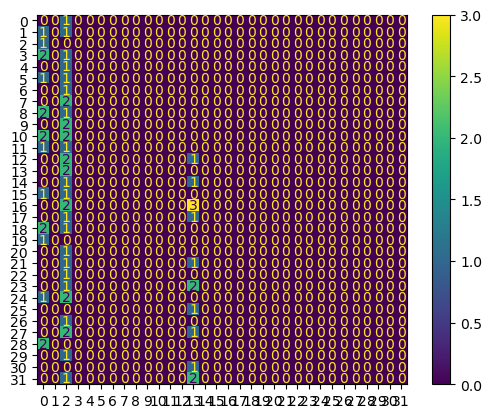

In [7]:
# Confusion matrix
cm = metrics.confusion_matrix(y_test, y_predict_labels)
display_labels = sorted(np.unique(target))
display = metrics.ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=display_labels)
display.plot(xticks_rotation='vertical')

In [8]:
# ROC curve
from sklearn.preprocessing import label_binarize

sorted_classes = sorted(np.unique(target))
y_test_bin = label_binarize(y_test, classes=sorted_classes)

distances = final_model.transform(X_test_norm)
negative_distances = -distances
exp_distances = np.exp(negative_distances - negative_distances.max(axis=1, keepdims=True))
soft_scores = exp_distances / exp_distances.sum(axis=1, keepdims=True)

label_to_sorted_idx = {lbl: i for i, lbl in enumerate(sorted_classes)}
column_order = [label_to_sorted_idx[cluster_to_label[c]] for c in range(final_model.n_clusters)]
y_scores = np.zeros_like(soft_scores)
for cluster_column, sorted_column in enumerate(column_order):
    y_scores[:, sorted_column] = soft_scores[:, cluster_column]

fpr = dict()
tpr = dict()
roc_auc = dict()
n_classes = y_test_bin.shape[1]

for i in range(n_classes):
    fpr[i], tpr[i], _ = metrics.roc_curve(y_test_bin[:, i], y_scores[:, 1])
    roc_auc[i] = metrics.auc(fpr[i], tpr[i])

IndexError: index 13 is out of bounds for axis 1 with size 3

In [9]:
# Plot the ROC curve for each class

import matplotlib.pyplot as plt
plt.figure()
classes = np.unique(target)
colors = ['blue', 'red', 'green', 'cyan', 'magenta', 'yellow', 'black', 'orange', 'purple']
for i, cur_class, color in zip(range(n_classes), classes, colors):
    plt.plot(fpr[i], tpr[i], color=color, lw=2,
             label='ROC curve of class {0} (area = {1:0.2f})'
             ''.format(cur_class, roc_auc[i]))

plt.plot([0, 1], [0, 1], "k--", lw=2)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Receiver Operating Characteristic (ROC) Curve for K-Means")
plt.legend(loc="lower right")
plt.show()

NameError: name 'n_classes' is not defined

<Figure size 640x480 with 0 Axes>